# 2D cond 1D — Behavior Under Infeasible / Adversarial Targets

`Exp_2D_cond_1D.ipynb` builds its target `G(Y)` by slicing the true joint `P(X,Y)` at a chosen `x_star`, so an exact match (`L(x_star) = 0`) is guaranteed by construction. This notebook studies the complementary case: **target distributions `G` that do not correspond exactly to any single conditional `P(Y|X=x)`**, and checks how MLGD and MLGD-F behave when exact matching is impossible.

### Scenario
This trimmed notebook runs a single scenario:

| name | construction | intent |
|---|---|---|
| `Adversarial_Bimodal` | `0.5 * P(Y\|X=x1) + 0.5 * P(Y\|X=x2)` for well-separated `x1, x2` (config: `S2_X1`, `S2_X2`, `S2_WEIGHT`) | target requires two conditionals at once, no single `x` reproduces it |


In [1]:
import os
# ============================================================
# CONFIG
# Reuses the SAME joint GMM + checkpoints as EXPERIMENT_NAME below (feasible-target notebook).
# Results from THIS notebook are written to a separate results dir so nothing is overwritten.
# ============================================================
BASE_EXPERIMENT_NAME = "2D_cond_1D"          # source of GMM params + model checkpoints (unchanged)
EXPERIMENT_NAME       = "2D_cond_1D_adversarial_bimodal"   # where THIS notebook writes its own results
GLOBAL_SEED           = 42

BASE_DIR        = os.path.normpath(os.path.join(os.getcwd(), ".."))
PARAMS_DIR      = f"{BASE_DIR}/params"
CHECKPOINT_DIR  = f"{BASE_DIR}/checkpoints/{BASE_EXPERIMENT_NAME}"   # reuse existing checkpoints, no retraining
RESULTS_DIR     = f"{BASE_DIR}/results/{EXPERIMENT_NAME}"

# Architecture (must match the checkpoints being loaded)
NBLOCKS, NUNITS       = 3, 128
NBLOCKS_CM, NUNITS_CM = 3, 128
DIFFUSION_STEPS       = 100
CONDITION_ON          = 1   # dim(x)=1, dim(y)=1

# Optimization: 3 scenarios x 2 methods x N_ATTEMP_OPTIM runs
N_ATTEMP_OPTIM             = 25
NSAMPLES_IN_OPTIM_FOR_MMD  = 250
NUM_X_T_LGD                = 3
NUM_X_T_LGD_CM              = 3

# Scenario knobs
S2_X1, S2_X2  = -3.0, 3.0   # S2: the two x-locations mixed together
S2_WEIGHT     = 0.5         # S2: mixture weight on the x1 conditional
S3_MEAN       = -12.0    # S3: target mean, well outside the joint's Y-range (~[-8, 8])
S3_VAR        = 12.     # S3: target variance (typical of a single component)

# Oracle grid search
ORACLE_GRID_LO, ORACLE_GRID_HI, ORACLE_GRID_N = -15.0, 30.0, 900
ORACLE_REFINE_N = 400


In [2]:
import os, sys
src_path = os.path.normpath(os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f"src path on sys.path: {src_path}")


src path on sys.path: /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/src


In [3]:
# Install dependencies if needed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "flow_matching", "POT", "-q"])


0

In [4]:
import os, sys, time, json
import importlib
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from tqdm import trange

import Diffusion
import LossFunctions
import ConsistencyModels
import dist_utils
import Optimization
import experiment_utils
from ConsistencyModels import ConsistencyModeliCT
from LossFunctions import MMDLoss, RBF

for mod in [Diffusion, LossFunctions, ConsistencyModels,
            dist_utils, Optimization, experiment_utils]:
    importlib.reload(mod)

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Imports done.")


Imports done.


/sci/labs/orzuk/ori_m/dps_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
env_info = experiment_utils.get_environment_info()
experiment_utils.print_environment_info(env_info)


ENVIRONMENT INFO
  timestamp: 2026-07-29T08:20:57.945855
  torch_version: 2.5.1+cu121
  cuda_available: True
  cuda_version: 12.1
  device_name: NVIDIA L4
  packages: {'torch': '2.5.1+cu121', 'numpy': '2.4.3', 'flow_matching': '1.0.10', 'POT': '0.9.6.post1', 'matplotlib': '3.10.8', 'pandas': '3.0.2', 'tqdm': '4.67.3'}
  packages:


In [6]:
experiment_utils.set_global_seed(GLOBAL_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


[Seed] All random seeds set to 42
Using device: cuda


## Load the joint GMM (same one `Exp_2D_cond_1D.ipynb` uses)

In [7]:
loaded = experiment_utils.load_gmm_params(PARAMS_DIR, BASE_EXPERIMENT_NAME)
if loaded is None:
    raise FileNotFoundError(
        f"Could not find saved GMM params for '{BASE_EXPERIMENT_NAME}' in {PARAMS_DIR}. "
        "Run Exp_2D_cond_1D.ipynb at least once first (it generates and saves the joint GMM)."
    )
mu_list, Sigma_list, alpha, mog_means_true, mog_variances_true, weights_true, x_star = loaded
mu_list    = [mu.float() for mu in mu_list]
Sigma_list = [cov.float() for cov in Sigma_list]
alpha      = alpha.float()
print(f"Loaded joint GMM with {len(mu_list)} components. Reference x_star = {x_star.item()}")


[GMM] Parameters loaded from /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/params/2D_cond_1D_gmm_params.pt
Loaded joint GMM with 11 components. Reference x_star = -5


/sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/src/experiment_utils.py:112: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path)


## Load pretrained models (no retraining — reuses `2D_cond_1D` checkpoints)

In [8]:
B_dummy = torch.cat([m.view(1, -1) for m in mu_list], dim=0)
nfeatures = B_dummy.shape[1] - CONDITION_ON

Cos_ConsistencyModeliCT = ConsistencyModeliCT(
    nfeatures=nfeatures, condition_on=CONDITION_ON, nunits=NUNITS_CM, depth=NBLOCKS_CM
)
ok_cm = experiment_utils.load_checkpoint_with_hf_fallback(
    Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR, BASE_EXPERIMENT_NAME, GLOBAL_SEED, device
)
assert ok_cm, "Failed to load the CM (MLGD-F) checkpoint — run Exp_2D_cond_1D.ipynb once first."

model_cond = Diffusion.DiffusionModel(
    nfeatures=B_dummy.shape[1], nblocks=NBLOCKS, nunits=NUNITS,
    condition=True, condition_on=CONDITION_ON, diffusion_steps=DIFFUSION_STEPS
)
ok_cond = experiment_utils.load_checkpoint_with_hf_fallback(
    model_cond, "Diffusion_cond", CHECKPOINT_DIR, BASE_EXPERIMENT_NAME, GLOBAL_SEED, device
)
assert ok_cond, "Failed to load the conditional diffusion (MLGD) checkpoint."

model_uncond = Diffusion.DiffusionModel(
    nfeatures=CONDITION_ON, nblocks=NBLOCKS, nunits=NUNITS,
    condition=False, diffusion_steps=DIFFUSION_STEPS
)
ok_uncond = experiment_utils.load_checkpoint_with_hf_fallback(
    model_uncond, "Diffusion_uncond", CHECKPOINT_DIR, BASE_EXPERIMENT_NAME, GLOBAL_SEED, device
)
assert ok_uncond, "Failed to load the unconditional diffusion checkpoint."
print("All checkpoints loaded.")


[Checkpoint] CM loaded from /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt
[Checkpoint] Diffusion_cond loaded from /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_cond_seed42.pt
[Checkpoint] Diffusion_uncond loaded from /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_uncond_seed42.pt
All checkpoints loaded.


/sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/src/experiment_utils.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path

## Build the infeasible / adversarial targets

Each target is just a `(means, variances, weights)` GMM over `Y` — exactly the same object type `Exp_2D_cond_1D.ipynb` builds from a single `x_star`. `optimize_LGD` doesn't know or care where it came from.

In [9]:
def true_conditional_at(x_val, threshold=0.01):
    """Analytic P(Y|X=x_val) for the joint GMM, filtered/normalized (same as main notebook)."""
    x = torch.tensor([float(x_val)])
    mu_c, S_c = dist_utils.compute_conditionals(mu_list, Sigma_list, x)
    w_c = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x)
    return dist_utils.filter_and_normalize(mu_c, S_c, w_c, threshold=threshold)

def scenario_loss(x_val, tgt_mu, tgt_S, tgt_w):
    """Exact L2-GMM loss L(x) = || P(Y|X=x) - G ||^2 at a scalar x, closed form (no sampling)."""
    mu_c, S_c, w_c = true_conditional_at(x_val)
    return dist_utils.gmm_l2_distance(mu_c, S_c, w_c, tgt_mu, tgt_S, tgt_w)

def oracle_grid_search(tgt_mu, tgt_S, tgt_w,
                        lo=ORACLE_GRID_LO, hi=ORACLE_GRID_HI,
                        n=ORACLE_GRID_N, n_refine=ORACLE_REFINE_N):
    """L*(G) = min_x L(x), found by dense grid search then a local refine pass."""
    xs = torch.linspace(lo, hi, n)
    losses = torch.tensor([scenario_loss(x.item(), tgt_mu, tgt_S, tgt_w) for x in xs])
    i = int(losses.argmin())
    lo2 = xs[max(i - 2, 0)].item()
    hi2 = xs[min(i + 2, n - 1)].item()
    xs2 = torch.linspace(lo2, hi2, n_refine)
    losses2 = torch.tensor([scenario_loss(x.item(), tgt_mu, tgt_S, tgt_w) for x in xs2])
    j = int(losses2.argmin())
    return xs2[j].item(), losses2[j].item(), (xs, losses)   # also return the full curve for plotting


In [10]:
scenarios = {}

# --- Adversarial_Bimodal: 0.5/0.5 mixture of two well-separated conditionals ---
mu_a, Sa, wa = true_conditional_at(S2_X1)
mu_b, Sb, wb = true_conditional_at(S2_X2)
mu2 = torch.cat([mu_a, mu_b], dim=0)
S2_ = torch.cat([Sa, Sb], dim=0)
w2  = torch.cat([S2_WEIGHT * wa / wa.sum(), (1 - S2_WEIGHT) * wb / wb.sum()], dim=0)
scenarios["Adversarial_Bimodal"] = dict(mog_means=mu2, mog_variances=S2_, weights=w2)

# --- Oracle ---
for name, sc in scenarios.items():
    x_oracle, L_star, curve = oracle_grid_search(sc["mog_means"], sc["mog_variances"], sc["weights"])
    sc["x_oracle"], sc["L_star"], sc["curve"] = x_oracle, L_star, curve
    print(f"{name:22s} | x_oracle={x_oracle:7.3f} | L*={L_star:.6f}")


/sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/src/dist_utils.py:356: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  exponent = -0.5 * diff.T @ Sigma_22_inv @ diff


Adversarial_Bimodal    | x_oracle= -3.292 | L*=0.135523


## Loss curve `L(x)` per scenario

Since `L(x)` is closed-form, we can plot the *entire* loss landscape over `x` for each target — this is the cheapest possible diagnostic for whether MLGD / MLGD-F land near the true global minimum or get stuck somewhere else.

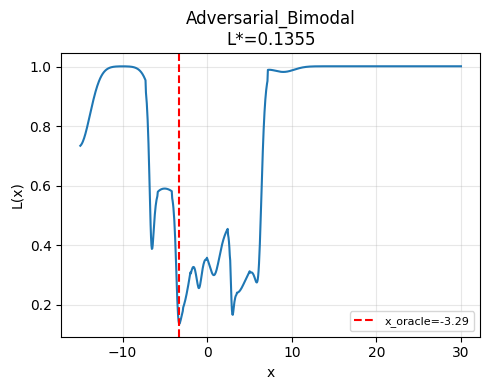

In [11]:
fig, axes = plt.subplots(1, len(scenarios), figsize=(5 * len(scenarios), 4), sharey=True)
if len(scenarios) == 1:
    axes = [axes]
for ax, (name, sc) in zip(axes, scenarios.items()):
    xs, losses = sc["curve"]
    ax.plot(xs.numpy(), losses.numpy(), lw=1.5)
    ax.axvline(sc["x_oracle"], color="red", ls="--", label=f"x_oracle={sc['x_oracle']:.2f}")
    ax.set_title(f"{name}\nL*={sc['L_star']:.4f}")
    ax.set_xlabel("x"); ax.set_ylabel("L(x)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Optimize under each target: MLGD vs MLGD-F

Identical call to `Optimization.optimize_LGD` as the main notebook — only the `(mog_means, mog_variances, weights)` argument changes per scenario.

In [12]:
def run_method(model_cond_obj, CM_flag, num_x_t, sc, n_attempts):
    x_preds, l2_gmm_list, l2_xstar_list, l2_xoracle_list, times, final_losses = [], [], [], [], [], []
    for i in trange(n_attempts, leave=False):
        run_seed = experiment_utils.set_run_seed(GLOBAL_SEED, i)   # same seed for both methods, attempt i
        t0 = time.time()
        best_x_t, _, final_loss = Optimization.optimize_LGD(
            model_uncond, model_cond_obj,
            sc["mog_means"], sc["mog_variances"], sc["weights"],
            mu_list, Sigma_list, alpha,
            nsamples=NSAMPLES_IN_OPTIM_FOR_MMD, loss="MMD", device=device,
            CM=CM_flag, FLAG=False, num_x_t=num_x_t,
        )
        times.append(time.time() - t0)
        final_losses.append(final_loss)
        x_preds.append(best_x_t)

        x_pred = best_x_t.float().view(-1).cpu()
        mu_p, S_p, w_p = true_conditional_at(x_pred.item())
        l2_gmm = dist_utils.gmm_l2_distance(mu_p, S_p, w_p, sc["mog_means"], sc["mog_variances"], sc["weights"])

        l2_gmm_list.append(l2_gmm)
        l2_xstar_list.append((x_pred - x_star.float().cpu()).pow(2).sum().sqrt().item())
        l2_xoracle_list.append(abs(x_pred.item() - sc["x_oracle"]))
    return dict(x_pred=x_preds, l2_gmm=l2_gmm_list, l2_xstar=l2_xstar_list,
                l2_xoracle=l2_xoracle_list, times=times, final_loss=final_losses)

all_results = {}
for name, sc in scenarios.items():
    print(f"\n=== {name} (L*={sc['L_star']:.6f}) ===")
    res_mlgd   = run_method(model_cond, False, NUM_X_T_LGD,    sc, N_ATTEMP_OPTIM)
    res_mlgdf  = run_method(Cos_ConsistencyModeliCT, True, NUM_X_T_LGD_CM, sc, N_ATTEMP_OPTIM)
    all_results[name] = {"MLGD": res_mlgd, "MLGD-F": res_mlgdf}



=== Adversarial_Bimodal (L*=0.135523) ===


## Results: regret against the oracle

`regret = L(x_pred) - L*` — how far each method lands from the *best achievable* loss, not from zero. On S0 this should match the main notebook's numbers (regret ≈ L2-to-x* result since `L*≈0`); on S1/S2/S3 it isolates optimization quality from target-infeasibility.

In [16]:
def summary_row_regret(method_name, scenario_name, res, L_star, top_ks=(1, 5)):
    l2_gmm     = np.array(res["l2_gmm"])
    regret     = l2_gmm - L_star
    times      = np.array(res["times"])
    final_loss = np.array([fl.item() if hasattr(fl, "item") else fl for fl in res["final_loss"]])

    row = {
        "Scenario":     scenario_name,
        "Method":       method_name,
        "L* (oracle)":  f"{L_star:.4f}",
        "L2-GMM":       f"{l2_gmm.mean():.4f} ± {l2_gmm.std():.4f}",
        "Regret":       f"{regret.mean():.4f} ± {regret.std():.4f}",
        "Time (s)":     f"{times.mean():.2f} ± {times.std():.2f}",
        "N restarts":   len(l2_gmm),
    }

    # Top-k selection by the optimizer's own criterion (final MMD loss), not by exact L2-GMM.
    for top_k in top_ks:
        k = min(top_k, len(final_loss))
        top_idx = np.argsort(final_loss)[:k]
        l2_gmm_top = l2_gmm[top_idx]
        regret_top = regret[top_idx]
        if k == 1:
            row[f"Top-{k} L2-GMM"] = f"{l2_gmm_top[0]:.4f}"
            row[f"Top-{k} Regret"] = f"{regret_top[0]:.4f}"
        else:
            row[f"Top-{k} L2-GMM"] = f"{l2_gmm_top.mean():.4f} ± {l2_gmm_top.std():.4f}"
            row[f"Top-{k} Regret"] = f"{regret_top.mean():.4f} ± {regret_top.std():.4f}"
    return row

rows = []
for name, sc in scenarios.items():
    for method in ["MLGD", "MLGD-F"]:
        rows.append(summary_row_regret(method, name, all_results[name][method], sc["L_star"], top_ks=(1, 5)))
df = pd.DataFrame(rows).set_index(["Scenario", "Method"])
display(df)

L* (oracle)           L2-GMM           Regret  \
Scenario            Method                                                 
Adversarial_Bimodal MLGD        0.1355  0.3214 ± 0.2179  0.1859 ± 0.2179   
                    MLGD-F      0.1355  0.3054 ± 0.1214  0.1699 ± 0.1214   

                                Time (s)  N restarts Top-1 L2-GMM  \
Scenario            Method                                          
Adversarial_Bimodal MLGD    51.96 ± 0.42          25       0.1984   
                    MLGD-F   6.09 ± 0.11          25       0.3893   

                           Top-1 Regret     Top-5 L2-GMM     Top-5 Regret  
Scenario            Method                                                 
Adversarial_Bimodal MLGD         0.0629  0.1992 ± 0.0034  0.0637 ± 0.0034  
                    MLGD-F       0.2538  0.3689 ± 0.0148  0.2334 ± 0.0148

## Adversarial_Bimodal: loss landscape with restarts, and top-1 density comparison

Left: the analytic loss curve `L(x)` with every restart's `(x_pred, L(x_pred))` overlaid (top-1 per method highlighted with a star). Right: the target `G(Y)`, the oracle's density at `x_oracle`, and each method's top-1 (best `l2_gmm`) recovered density, all evaluated as actual pdfs over `y`.

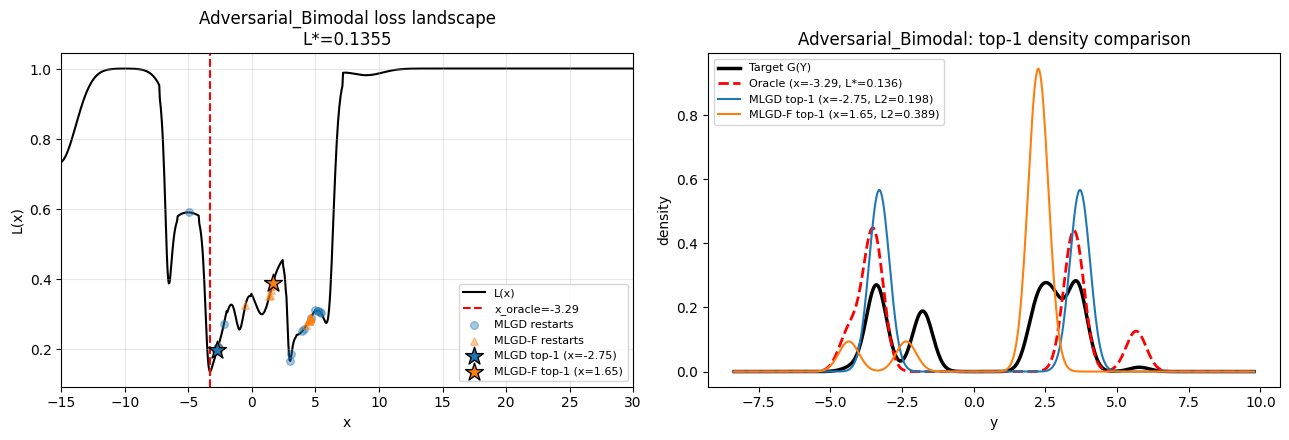

In [18]:
def gmm_pdf_1d(y_grid, means, variances, weights):
    """Univariate GMM density, evaluated on y_grid."""
    means_  = means.view(-1)
    vars_   = variances.view(-1)
    w_      = weights.view(-1)
    y = y_grid.view(-1, 1)
    comp_pdf = (1.0 / torch.sqrt(2 * torch.pi * vars_)) * torch.exp(-0.5 * (y - means_) ** 2 / vars_)
    return (comp_pdf * w_).sum(dim=1)
def best_restart_conditional(name, method):
    """Analytic conditional P(Y|X=x_pred) at the top-1 restart, selected by the optimizer's own
    final MMD loss (same criterion as the summary table's Top-1/Top-5 selection)."""
    res = all_results[name][method]
    final_loss = np.array([fl.item() if hasattr(fl, "item") else fl for fl in res["final_loss"]])
    best_i = int(np.argmin(final_loss))
    x_best = res["x_pred"][best_i].float().view(-1).cpu().item()
    mu_b, S_b, w_b = true_conditional_at(x_best)
    l2_gmm_at_best = np.array(res["l2_gmm"])[best_i]
    return x_best, mu_b, S_b, w_b, l2_gmm_at_best

name = "Adversarial_Bimodal"
sc = scenarios[name]

x_mlgd,  mu_mlgd,  S_mlgd,  w_mlgd,  l2_mlgd  = best_restart_conditional(name, "MLGD")
x_mlgdf, mu_mlgdf, S_mlgdf, w_mlgdf, l2_mlgdf = best_restart_conditional(name, "MLGD-F")
mu_or, S_or, w_or = true_conditional_at(sc["x_oracle"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: loss landscape, all restarts, top-1 highlighted ---
xs, losses = sc["curve"]
ax1.plot(xs.numpy(), losses.numpy(), lw=1.5, color="black", zorder=1, label="L(x)")
ax1.axvline(sc["x_oracle"], color="red", ls="--", zorder=1, label=f"x_oracle={sc['x_oracle']:.2f}")

x_mlgd_all  = [xt.float().view(-1).cpu().item() for xt in all_results[name]["MLGD"]["x_pred"]]
x_mlgdf_all = [xt.float().view(-1).cpu().item() for xt in all_results[name]["MLGD-F"]["x_pred"]]
l_mlgd_all  = all_results[name]["MLGD"]["l2_gmm"]
l_mlgdf_all = all_results[name]["MLGD-F"]["l2_gmm"]

ax1.scatter(x_mlgd_all,  l_mlgd_all,  s=30, alpha=0.4, color="tab:blue",   zorder=2, label="MLGD restarts")
ax1.scatter(x_mlgdf_all, l_mlgdf_all, s=30, alpha=0.4, color="tab:orange", marker="^", zorder=2, label="MLGD-F restarts")
ax1.scatter([x_mlgd],  [l2_mlgd],  s=180, color="tab:blue",   marker="*", edgecolor="black", zorder=3,
            label=f"MLGD top-1 (x={x_mlgd:.2f})")
ax1.scatter([x_mlgdf], [l2_mlgdf], s=180, color="tab:orange", marker="*", edgecolor="black", zorder=3,
            label=f"MLGD-F top-1 (x={x_mlgdf:.2f})")

ax1.set_xlim(xs.min().item(), xs.max().item())
ax1.set_title(f"{name} loss landscape\nL*={sc['L_star']:.4f}")
ax1.set_xlabel("x"); ax1.set_ylabel("L(x)"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# --- Right: top-1 density comparison: target vs oracle vs optimized ---
all_means = torch.cat([sc["mog_means"].view(-1), mu_or.view(-1), mu_mlgd.view(-1), mu_mlgdf.view(-1)])
y_lo, y_hi = all_means.min().item() - 4, all_means.max().item() + 4
y_grid = torch.linspace(y_lo, y_hi, 500)

pdf_target = gmm_pdf_1d(y_grid, sc["mog_means"], sc["mog_variances"], sc["weights"])
pdf_oracle = gmm_pdf_1d(y_grid, mu_or, S_or, w_or)
pdf_mlgd   = gmm_pdf_1d(y_grid, mu_mlgd, S_mlgd, w_mlgd)
pdf_mlgdf  = gmm_pdf_1d(y_grid, mu_mlgdf, S_mlgdf, w_mlgdf)

ax2.plot(y_grid.numpy(), pdf_target.numpy(), color="black", lw=2.5, label="Target G(Y)")
ax2.plot(y_grid.numpy(), pdf_oracle.numpy(), color="red", ls="--", lw=2,
         label=f"Oracle (x={sc['x_oracle']:.2f}, L*={sc['L_star']:.3f})")
ax2.plot(y_grid.numpy(), pdf_mlgd.numpy(), color="tab:blue", lw=1.5,
         label=f"MLGD top-1 (x={x_mlgd:.2f}, L2={l2_mlgd:.3f})")
ax2.plot(y_grid.numpy(), pdf_mlgdf.numpy(), color="tab:orange", lw=1.5,
         label=f"MLGD-F top-1 (x={x_mlgdf:.2f}, L2={l2_mlgdf:.3f})")

ax2.set_title(f"{name}: top-1 density comparison")
ax2.set_xlabel("y"); ax2.set_ylabel("density"); ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()


## Save results

In [15]:
def to_python(val):
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().tolist()
    if isinstance(val, np.ndarray):
        return val.tolist()
    if hasattr(val, "item"):
        return val.item()
    return val

out = {
    "experiment": EXPERIMENT_NAME,
    "base_experiment": BASE_EXPERIMENT_NAME,
    "seed": GLOBAL_SEED,
    "environment": env_info,
    "scenarios": {},
}
for name, sc in scenarios.items():
    out["scenarios"][name] = {
        "x_oracle": sc["x_oracle"],
        "L_star": sc["L_star"],
        "target_means": to_python(sc["mog_means"]),
        "target_variances": to_python(sc["mog_variances"]),
        "target_weights": to_python(sc["weights"]),
        "MLGD": {k: [to_python(v) for v in vs] for k, vs in all_results[name]["MLGD"].items()},
        "MLGD-F": {k: [to_python(v) for v in vs] for k, vs in all_results[name]["MLGD-F"].items()},
    }

path = os.path.join(RESULTS_DIR, f"{EXPERIMENT_NAME}_results_seed{GLOBAL_SEED}.json")
with open(path, "w") as f:
    json.dump(out, f, indent=2)
print(f"Results saved to {path}")


Results saved to /sci/labs/orzuk/ori_m/conditional-matching-paper/simulations/results/2D_cond_1D_adversarial_bimodal/2D_cond_1D_adversarial_bimodal_results_seed42.json
